### Deep Agents overview



Build agents that can plan, use subagents, and leverage file systems for complex tasks

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.


### When to use deep agents
Use deep agents when you need agents that can:

- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [1]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [2]:
from typing import Literal

In [3]:
### Tools- Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5, topic: Literal["general","sports","news","finance"]="general", include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)




In [36]:
from langchain.chat_models import init_chat_model

#model=init_chat_model("groq:qwen/qwen3-32b")
#model=init_chat_model("groq:qwen/qwen3.6-27b")
#model=init_chat_model("groq:llama-3.3-70b-versatile")
model=init_chat_model("ollama:glm-4.7:cloud")
model

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, model='glm-4.7:cloud')

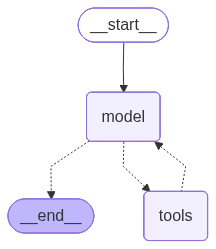

In [37]:
## Basic Agent
from langchain.agents import create_agent


simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

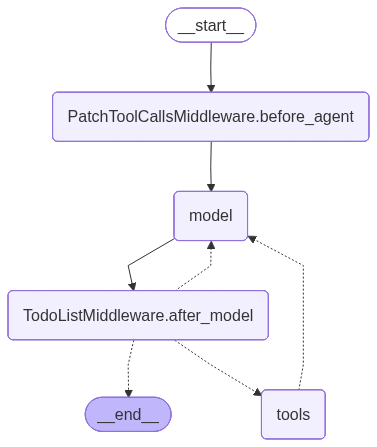

In [38]:
### Create a deep agent
## Prompt

## agent

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

## deepagents have middle ware attached. In middle ware you have hooks... like patch tool call hook, summarizationmiddleware hook, and todo hook that creates to do list to track how the execution is going on when task is assigned to agents

In [39]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "Explain the purpose and functionality of langchain deepagent?"}]})
result

{'messages': [HumanMessage(content='Explain the purpose and functionality of langchain deepagent?', additional_kwargs={}, response_metadata={}, id='04cc47ba-c585-4b4e-a1a7-02d333b81a0c'),
  AIMessage(content="I'll research LangChain's deep agent functionality for you.", additional_kwargs={}, response_metadata={'model': 'glm-4.7', 'created_at': '2026-06-21T11:40:59.886718278Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3622718904, 'load_duration': None, 'prompt_eval_count': 6275, 'prompt_eval_duration': None, 'eval_count': 131, 'eval_duration': None, 'logprobs': None, 'model_name': 'glm-4.7', 'model_provider': 'ollama'}, id='lc_run--019ee9fb-d54e-7742-824b-ce18a9f4a619-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'langchain deep agent purpose functionality', 'max_results': 10}, 'id': 'e36f81b7-d9ae-4e21-9b62-5e1fd87f6e46', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 6275, 'output_tokens': 131, 'total_tokens': 6406}),
  ToolMessa

In [29]:
result["messages"][-1].content

"The LangChain DeepAgent is a type of AI assistant designed to help users accomplish tasks using various tools. Here's an overview of its purpose and functionality:\n\n**Purpose:**\nThe primary purpose of the LangChain DeepAgent is to assist users in completing tasks efficiently and effectively. It acts as a personal AI assistant, providing guidance, performing tasks, and helping users manage complex objectives.\n\n**Functionality:**\n\n1. **Task Management:** The DeepAgent uses a tool called `write_todos` to manage and plan complex objectives. It breaks down large tasks into smaller, manageable steps, and tracks progress.\n2. **Tool Integration:** The DeepAgent has access to various tools, such as `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`, and `task`. These tools enable the agent to interact with a filesystem, read and write files, search for text, and launch subagents.\n3. **Subagent Spawning:** The DeepAgent can launch short-lived subagents using the `task` tool. 

In [30]:
result['files']

{}

In [35]:
# pip install -qU deepagents langchain-ollama
from deepagents import create_deep_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_deep_agent(
    model="ollama:glm-4.7:cloud",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='ca40a2c7-876f-4cb9-b64c-5df9a27d6c49'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'glm-4.7', 'created_at': '2026-06-21T11:32:27.791080875Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2272168257, 'load_duration': None, 'prompt_eval_count': 6226, 'prompt_eval_duration': None, 'eval_count': 63, 'eval_duration': None, 'logprobs': None, 'model_name': 'glm-4.7', 'model_provider': 'ollama'}, id='lc_run--019ee9f4-0a4b-7da1-972b-4875bfad7b72-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': '94dda219-1ac6-46d3-b301-0297858ef990', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 6226, 'output_tokens': 63, 'total_tokens': 6289}),
  ToolMessage(content="It's always sunny in San Francisco!", name='get_weather', id='4f9ebd0a-57ea-45af-b2bb-6a6e984f7e51', tool_call_id='94dda219-1ac6-46d3

In [40]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What are llm gateways? do the web search and provide me the results."}]})
result

{'messages': [HumanMessage(content='What are llm gateways? do the web search and provide me the results.', additional_kwargs={}, response_metadata={}, id='5dc2b04f-fa7a-4cca-9ed1-f873ac214176'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'glm-4.7', 'created_at': '2026-06-21T12:37:07.677946826Z', 'done': True, 'done_reason': 'stop', 'total_duration': 909088315, 'load_duration': None, 'prompt_eval_count': 6281, 'prompt_eval_duration': None, 'eval_count': 150, 'eval_duration': None, 'logprobs': None, 'model_name': 'glm-4.7', 'model_provider': 'ollama'}, id='lc_run--019eea2f-4336-7292-9306-9ab4ca205b2c-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'what are LLM gateways', 'max_results': 10}, 'id': 'ca5ff958-3da2-41de-b442-8516c17ede95', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 6281, 'output_tokens': 150, 'total_tokens': 6431}),
  ToolMessage(content='{"query": "what are LLM gateways", "follow_up_questions": null